<a href="https://colab.research.google.com/github/alkhurayjah/Task_DL/blob/main/Saad_alshahrani_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

✅ 2. Load Dataset

In [3]:
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(77338, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


✅ 3. Data Preprocessing

Handle missing values

In [5]:
df = df.fillna(df.median())
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Handle imbalance

In [6]:
print(df['Class'].value_counts())

Class
0.0    77150
1.0      188
Name: count, dtype: int64


Split features and target

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

Train-test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Normalize data

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

maps

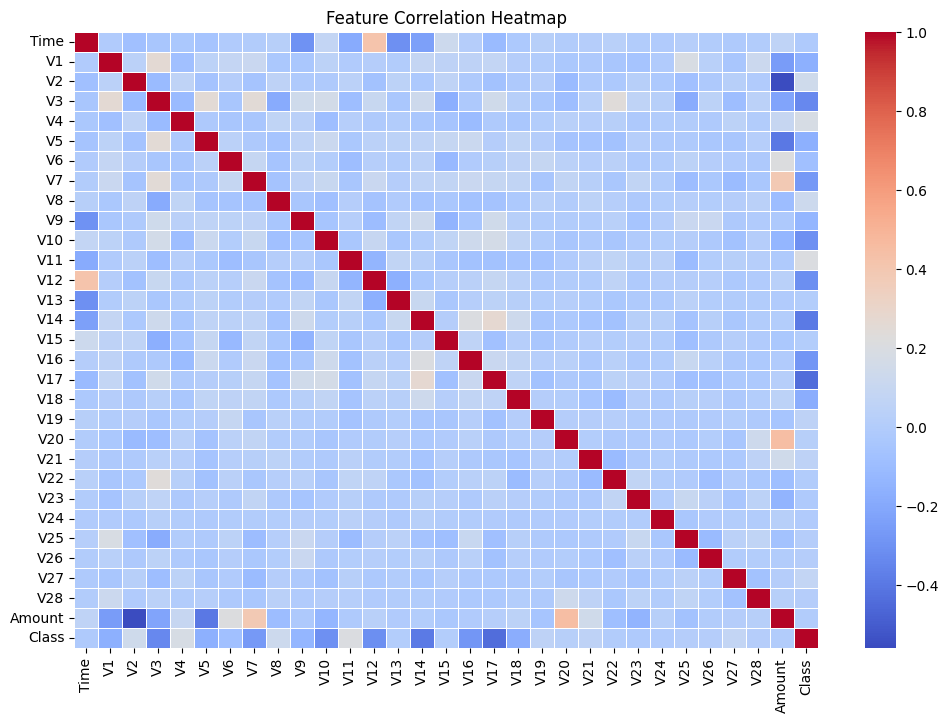

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

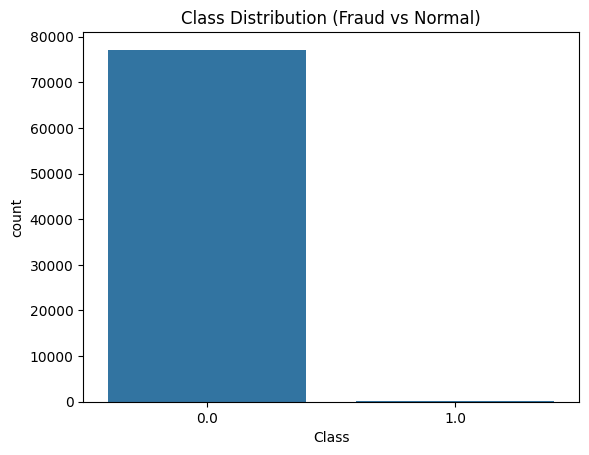

In [22]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Fraud vs Normal)")
plt.show()

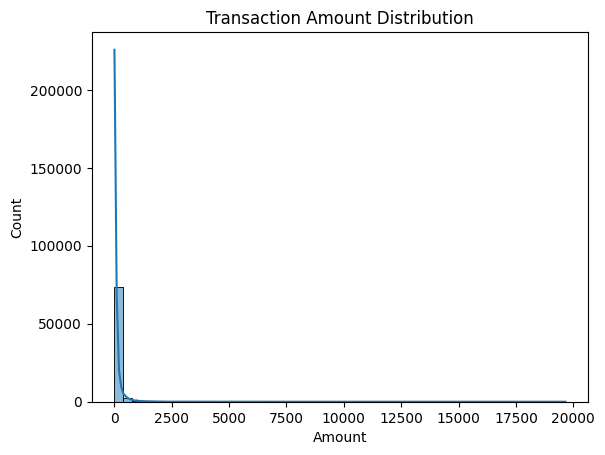

In [23]:
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

✅ 4. Build ANN Model

In [10]:
model = models.Sequential([

    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                 kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ 5. Compile Model

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

✅ 6. Add Early Stopping

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

✅ 7. Train Model

In [13]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9896 - loss: 0.1553 - val_accuracy: 0.9977 - val_loss: 0.0743
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9982 - loss: 0.0633 - val_accuracy: 0.9986 - val_loss: 0.0493
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9986 - loss: 0.0418 - val_accuracy: 0.9990 - val_loss: 0.0328
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9990 - loss: 0.0274 - val_accuracy: 0.9990 - val_loss: 0.0223
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9989 - loss: 0.0189 - val_accuracy: 0.9990 - val_loss: 0.0156
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9988 - loss: 0.0135 - val_accuracy: 0.9990 - val_loss: 0.0116
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0099 - val_accuracy: 0.9990 - val_loss: 0.0090
Epoch 8/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9991 - loss: 0.0078 - val_accuracy: 0.

✅ 8. Evaluate Model

In [14]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[15419    11]
 [    6    32]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15430
         1.0       0.74      0.84      0.79        38

    accuracy                           1.00     15468
   macro avg       0.87      0.92      0.89     15468
weighted avg       1.00      1.00      1.00     15468



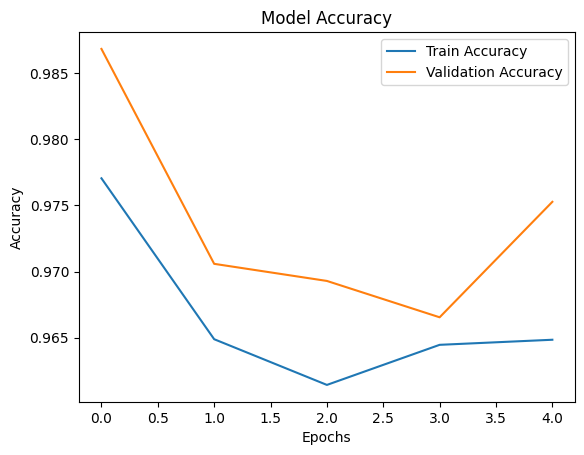

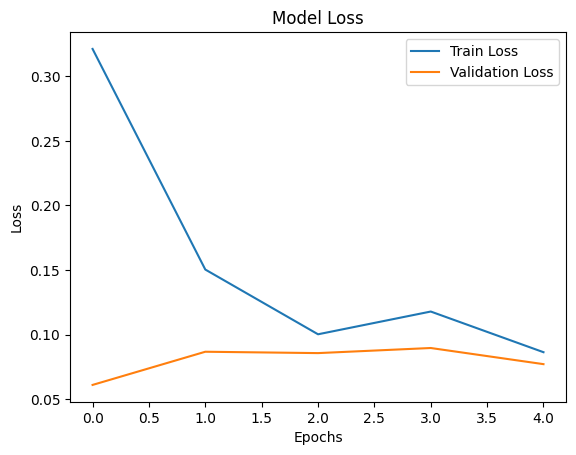

In [24]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

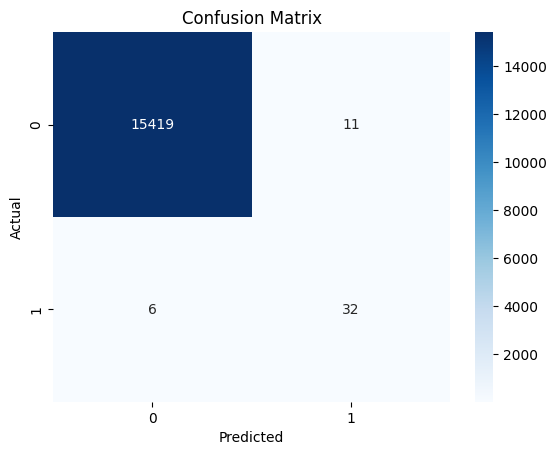

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


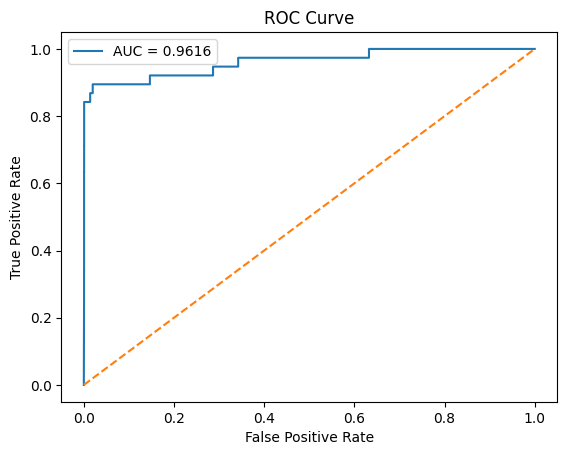

In [26]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,829 (54.02 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,220 (36.02 KB)

✅ 9. Save Model

In [15]:
model.save("fraud_detection_model.h5")

✅ 10. Load Model

In [16]:
loaded_model = tf.keras.models.load_model("fraud_detection_model.h5")

✅ 11. Inference Function

In [17]:
def predict_transaction(sample):
    sample = scaler.transform([sample])
    prob = loaded_model.predict(sample)[0][0]

    if prob > 0.5:
        return "Fraud ❌"
    else:
        return "Normal ✅"

improve performance

In [18]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.5012151652624757), 1: np.float64(206.23333333333332)}


In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9770 - loss: 0.3212 - val_accuracy: 0.9868 - val_loss: 0.0610
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9649 - loss: 0.1503 - val_accuracy: 0.9706 - val_loss: 0.0867
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9614 - loss: 0.1002 - val_accuracy: 0.9693 - val_loss: 0.0856
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9645 - loss: 0.1178 - val_accuracy: 0.9665 - val_loss: 0.0896
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9648 - loss: 0.0863 - val_accuracy: 0.9753 - val_loss: 0.0771
